In [1]:
import sys
import os
import socket

print("Python:", sys.executable)
print("CWD:", os.getcwd())
print("Host:", socket.gethostname())

Python: /opt/conda/bin/python
CWD: /home/jovyan/work
Host: 14ca9b772c28


In [2]:
from dask.distributed import Client

client = Client("tcp://dask-scheduler:8786")

print("Dashboard:", client.dashboard_link)
print("Workers:", client.scheduler_info()["workers"].keys())

Dashboard: http://dask-scheduler:8787/status
Workers: dict_keys(['tcp://172.18.0.3:44843'])


In [3]:
from pathlib import Path

DASK_JOBS = Path("/home/jovyan/dask_jobs")

print("Exists:", DASK_JOBS.exists())
print("Files:")

for file in DASK_JOBS.glob("*"):
    print(file.name)

Exists: True
Files:
.ipynb_checkpoints
benchmark_dask_vs_pandas.py
benchmark_data
benchmark_report.html
dask_4nodos_6partes.py
dask_demo.py
distributed_sales_6parts
pipeline_secop.py
q1_concentracion_territorial.py


In [4]:
import dask.dataframe as dd

ddf = dd.read_csv(
    DATA_GLOB,
    dtype=str,
    assume_missing=True,
    blocksize="64MB"
)

print("Rows:", ddf.shape[0].compute())
print("Partitions:", ddf.npartitions)
print("Columns:", list(ddf.columns))

/opt/conda/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


NameError: name 'DATA_GLOB' is not defined

In [6]:
print("Dtypes:")
print(ddf.dtypes)

Dtypes:
entidad                           string[pyarrow]
nit_entidad                       string[pyarrow]
departamento_entidad              string[pyarrow]
ciudad_entidad                    string[pyarrow]
ordenentidad                      string[pyarrow]
codigo_pci                        string[pyarrow]
id_del_proceso                    string[pyarrow]
referencia_del_proceso            string[pyarrow]
ppi                               string[pyarrow]
id_del_portafolio                 string[pyarrow]
nombre_del_procedimiento          string[pyarrow]
descripci_n_del_procedimiento     string[pyarrow]
fase                              string[pyarrow]
fecha_de_publicacion_del          string[pyarrow]
fecha_de_ultima_publicaci         string[pyarrow]
fecha_de_publicacion_fase         string[pyarrow]
fecha_de_publicacion_fase_1       string[pyarrow]
fecha_de_publicacion              string[pyarrow]
fecha_de_publicacion_fase_2       string[pyarrow]
fecha_de_publicacion_fase_3       string[p

In [7]:
# SEGMENTO 6B — Ultra safe preview

preview = ddf.head(5)

first_10_cols = list(preview.columns[:10])

print("Preview shape:", preview.shape)
print("Total columns:", len(preview.columns))

for row_idx in range(len(preview)):
    print(f"\nROW {row_idx + 1}")
    for col in first_10_cols:
        value = preview[col].astype("object").tolist()[row_idx]
        print(f"{col}: {value}")

Preview shape: (5, 59)
Total columns: 59

ROW 1
entidad: DEPARTAMENTO ADMINISTRATIVO NACIONAL DE ESTADISTICA (DANE)
nit_entidad: 899999027
departamento_entidad: Distrito Capital de Bogotá
ciudad_entidad: Bogotá
ordenentidad: Nacional
codigo_pci: Centralizada
id_del_proceso: CO1.REQ.2577563
referencia_del_proceso: EDP-545-2022
ppi: 700474109
id_del_portafolio: CO1.BDOS.2503732

ROW 2
entidad: ALCALDIA LOCAL DE SUMAPAZ
nit_entidad: 899999061
departamento_entidad: Distrito Capital de Bogotá
ciudad_entidad: Bogotá
ordenentidad: Territorial
codigo_pci: Centralizada
id_del_proceso: CO1.REQ.5912737
referencia_del_proceso: FDRSCD-064-2024 (103702)
ppi: 702096124
id_del_portafolio: CO1.BDOS.5796124

ROW 3
entidad: CENAC AVIACION
nit_entidad: 830039207
departamento_entidad: Distrito Capital de Bogotá
ciudad_entidad: No Definido
ordenentidad: Nacional
codigo_pci: Centralizada
id_del_proceso: CO1.REQ.8610154
referencia_del_proceso: SASD-191-CENACAVIACION-2025 (Manifestación de interés (Menor Cuant

In [23]:
ddf = ddf.astype("object")

In [8]:
# SEGMENTO 7 — Standardize column names

def normalize_column_name(col: str) -> str:
    col = str(col).strip().lower()
    col = col.replace(" ", "_")
    col = col.replace(".", "")
    col = col.replace("-", "_")
    col = col.replace("/", "_")
    col = col.replace("\\", "_")
    col = col.replace("(", "")
    col = col.replace(")", "")
    col = col.replace("__", "_")
    return col


ddf.columns = [normalize_column_name(c) for c in ddf.columns]

print("Total columns:", len(ddf.columns))
print("Normalized columns:")

for i, col in enumerate(ddf.columns):
    print(i, col)

Total columns: 59
Normalized columns:
0 entidad
1 nit_entidad
2 departamento_entidad
3 ciudad_entidad
4 ordenentidad
5 codigo_pci
6 id_del_proceso
7 referencia_del_proceso
8 ppi
9 id_del_portafolio
10 nombre_del_procedimiento
11 descripci_n_del_procedimiento
12 fase
13 fecha_de_publicacion_del
14 fecha_de_ultima_publicaci
15 fecha_de_publicacion_fase
16 fecha_de_publicacion_fase_1
17 fecha_de_publicacion
18 fecha_de_publicacion_fase_2
19 fecha_de_publicacion_fase_3
20 precio_base
21 modalidad_de_contratacion
22 justificaci_n_modalidad_de
23 duracion
24 unidad_de_duracion
25 fecha_de_recepcion_de
26 fecha_de_apertura_de_respuesta
27 fecha_de_apertura_efectiva
28 ciudad_de_la_unidad_de
29 nombre_de_la_unidad_de
30 proveedores_invitados
31 proveedores_con_invitacion
32 visualizaciones_del
33 proveedores_que_manifestaron
34 respuestas_al_procedimiento
35 respuestas_externas
36 conteo_de_respuestas_a_ofertas
37 proveedores_unicos_con
38 numero_de_lotes
39 estado_del_procedimiento
40 id_esta

In [9]:
# SEGMENTO 8 — Semantic dictionary for business question 1

COLUMNAS_Q1 = [
    "departamento",
    "valor_adjudicado",
    "fecha_publicacion",
    "estado_adjudicacion"
]

DICCIONARIO_SEMANTICO_Q1 = {
    "departamento": [
        "departamento_entidad",
        "departamento",
        "departamento_proveedor"
    ],
    "valor_adjudicado": [
        "valor_total_adjudicacion",
        "valor_adjudicado",
        "valor_del_contrato",
        "precio_base",
        "precio_base_num"
    ],
    "fecha_publicacion": [
        "fecha_de_publicacion_del",
        "fecha_de_publicacion",
        "fecha_publicacion",
        "fecha_de_publicacion_fase",
        "fecha_de_ultima_publicaci"
    ],
    "estado_adjudicacion": [
        "adjudicado",
        "estado_adjudicacion",
        "estado_del_procedimiento",
        "estado_resumen",
        "fase"
    ]
}


def resolver_columna_semantica(ddf, candidatos):
    """
    Returns the first existing column from a list of semantic candidates.
    """
    for col in candidatos:
        if col in ddf.columns:
            return col
    return None


columnas_resueltas = {}

for nombre_final, candidatos in DICCIONARIO_SEMANTICO_Q1.items():
    columna_origen = resolver_columna_semantica(ddf, candidatos)
    columnas_resueltas[nombre_final] = columna_origen

print("Resolved semantic columns:")

for nombre_final, columna_origen in columnas_resueltas.items():
    print(f"{nombre_final:<25} <- {columna_origen}")

faltantes = [
    nombre_final 
    for nombre_final, columna_origen in columnas_resueltas.items() 
    if columna_origen is None
]

print("\nMissing semantic columns:", faltantes)

Resolved semantic columns:
departamento              <- departamento_entidad
valor_adjudicado          <- valor_total_adjudicacion
fecha_publicacion         <- fecha_de_publicacion_del
estado_adjudicacion       <- adjudicado

Missing semantic columns: []


In [10]:
# SEGMENTO 9 — Create Q1 analytical dataframe with only the 4 required variables

columnas_validas = {
    nombre_final: columna_origen
    for nombre_final, columna_origen in columnas_resueltas.items()
    if columna_origen is not None
}

if len(columnas_validas) < 4:
    print("WARNING: Not all required semantic columns were found.")
    print("Columns found:", columnas_validas)
    print("Missing:", faltantes)

# Select original columns
ddf_q1 = ddf[list(columnas_validas.values())].copy()

# Rename to clean semantic names
rename_dict = {
    columna_origen: nombre_final
    for nombre_final, columna_origen in columnas_validas.items()
}

ddf_q1 = ddf_q1.rename(columns=rename_dict)

print("Q1 dataframe columns:")
print(list(ddf_q1.columns))

print("\nQ1 preview:")
preview = ddf_q1.head(5).astype("object").to_dict(orient="records")

for i, row in enumerate(preview, start=1):
    print(f"\nROW {i}")
    for key, value in row.items():
        print(f"{key}: {value}")

Q1 dataframe columns:
['departamento', 'valor_adjudicado', 'fecha_publicacion', 'estado_adjudicacion']

Q1 preview:

ROW 1
departamento: Distrito Capital de Bogotá
valor_adjudicado: 0
fecha_publicacion: 2022-01-18T00:00:00.000
estado_adjudicacion: No

ROW 2
departamento: Distrito Capital de Bogotá
valor_adjudicado: 0
fecha_publicacion: 2024-03-08T00:00:00.000
estado_adjudicacion: No

ROW 3
departamento: Distrito Capital de Bogotá
valor_adjudicado: 40000
fecha_publicacion: 2025-07-23T00:00:00.000
estado_adjudicacion: Si

ROW 4
departamento: Antioquia
valor_adjudicado: 0
fecha_publicacion: 2026-01-18T00:00:00.000
estado_adjudicacion: No

ROW 5
departamento: Distrito Capital de Bogotá
valor_adjudicado: 0
fecha_publicacion: 2024-11-06T00:00:00.000
estado_adjudicacion: No


In [11]:
# SEGMENTO 10 — Clean Q1 analytical dataframe

import dask.dataframe as dd

# 1. Departamento
if "departamento" in ddf_q1.columns:
    ddf_q1["departamento"] = (
        ddf_q1["departamento"]
        .fillna("NO DEFINIDO")
        .astype(str)
        .str.strip()
        .str.upper()
        .str.replace(r"\s+", " ", regex=True)
    )

# 2. Valor adjudicado
if "valor_adjudicado" in ddf_q1.columns:
    ddf_q1["valor_adjudicado_original"] = ddf_q1["valor_adjudicado"]

    ddf_q1["valor_adjudicado"] = (
        ddf_q1["valor_adjudicado"]
        .fillna("")
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace("COP", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace(" ", "", regex=False)
        .str.strip()
    )

    ddf_q1["valor_adjudicado"] = dd.to_numeric(
        ddf_q1["valor_adjudicado"],
        errors="coerce"
    )

# 3. Fecha publicación
if "fecha_publicacion" in ddf_q1.columns:
    ddf_q1["fecha_publicacion_original"] = ddf_q1["fecha_publicacion"]

    ddf_q1["fecha_publicacion"] = dd.to_datetime(
        ddf_q1["fecha_publicacion"],
        errors="coerce",
        dayfirst=False
    )

# 4. Estado adjudicación
if "estado_adjudicacion" in ddf_q1.columns:
    ddf_q1["estado_adjudicacion"] = (
        ddf_q1["estado_adjudicacion"]
        .fillna("NO DEFINIDO")
        .astype(str)
        .str.strip()
        .str.upper()
        .str.replace(r"\s+", " ", regex=True)
    )

print("Q1 cleaning completed.")
print("Columns:", list(ddf_q1.columns))

Q1 cleaning completed.
Columns: ['departamento', 'valor_adjudicado', 'fecha_publicacion', 'estado_adjudicacion', 'valor_adjudicado_original', 'fecha_publicacion_original']


In [12]:
# SEGMENTO 11 — Validate Q1 dataframe quality, 4 variables + year

import pandas as pd

COLUMNAS_Q1 = [
    "departamento",
    "valor_adjudicado",
    "fecha_publicacion",
    "estado_adjudicacion"
]

# Keep only the 4 required variables
ddf_q1 = ddf_q1[COLUMNAS_Q1]

# Ensure fecha_publicacion is datetime
ddf_q1["fecha_publicacion"] = dd.to_datetime(
    ddf_q1["fecha_publicacion"],
    errors="coerce"
)

# Add year column
ddf_q1["anio_publicacion"] = ddf_q1["fecha_publicacion"].dt.year

rows_q1 = int(ddf_q1.shape[0].compute())

print("Rows Q1:", rows_q1)
print("Partitions Q1:", ddf_q1.npartitions)

print("\nDtypes:")
print(ddf_q1.dtypes.to_string())

# Null diagnosis for the 4 variables + year
nulls_q1_raw = ddf_q1.isna().sum().compute()

nulls_q1_df = pd.DataFrame({
    "column": list(nulls_q1_raw.index.astype(str)),
    "null_count": list(nulls_q1_raw.values)
})

nulls_q1_df["null_count"] = pd.to_numeric(
    nulls_q1_df["null_count"],
    errors="coerce"
).fillna(0).astype(int)

nulls_q1_df["null_percent"] = (
    nulls_q1_df["null_count"] / rows_q1 * 100
).round(2)

nulls_q1_df = nulls_q1_df.sort_values(
    by="null_count",
    ascending=False,
    ignore_index=True
)

print("\nNull diagnosis Q1:")
print(nulls_q1_df.to_string(index=False))

print("\nPreview Q1 cleaned:")
preview = ddf_q1.head(10)

records = preview.astype("object").to_dict(orient="records")

for i, row in enumerate(records, start=1):
    print(f"\nROW {i}")
    for key, value in row.items():
        print(f"{key}: {value}")

Rows Q1: 3000
Partitions Q1: 3

Dtypes:
departamento           string[pyarrow]
valor_adjudicado                 Int64
fecha_publicacion       datetime64[ns]
estado_adjudicacion    string[pyarrow]
anio_publicacion                 int32

Null diagnosis Q1:
             column  null_count  null_percent
  fecha_publicacion          20          0.67
   anio_publicacion          20          0.67
       departamento           0          0.00
   valor_adjudicado           0          0.00
estado_adjudicacion           0          0.00

Preview Q1 cleaned:

ROW 1
departamento: DISTRITO CAPITAL DE BOGOTÁ
valor_adjudicado: 0
fecha_publicacion: 2022-01-18 00:00:00
estado_adjudicacion: NO
anio_publicacion: 2022.0

ROW 2
departamento: DISTRITO CAPITAL DE BOGOTÁ
valor_adjudicado: 0
fecha_publicacion: 2024-03-08 00:00:00
estado_adjudicacion: NO
anio_publicacion: 2024.0

ROW 3
departamento: DISTRITO CAPITAL DE BOGOTÁ
valor_adjudicado: 40000
fecha_publicacion: 2025-07-23 00:00:00
estado_adjudicacion: SI
a

In [13]:
# SEGMENTO 13 — Export Q1 analytical dataframe to Parquet

q1_parquet_dir = OUTPUT_DIR / "q1_universo_analitico_parquet"

ddf_q1.to_parquet(
    str(q1_parquet_dir),
    engine="pyarrow",
    write_index=False,
    overwrite=True
)

print("Q1 analytical dataframe exported to:", q1_parquet_dir)

parquet_files = sorted(q1_parquet_dir.glob("*.parquet"))

print("Parquet files generated:", len(parquet_files))

for file in parquet_files:
    print(file)

Q1 analytical dataframe exported to: /home/jovyan/output/q1_universo_analitico_parquet
Parquet files generated: 3
/home/jovyan/output/q1_universo_analitico_parquet/part.0.parquet
/home/jovyan/output/q1_universo_analitico_parquet/part.1.parquet
/home/jovyan/output/q1_universo_analitico_parquet/part.2.parquet


In [14]:
# SEGMENTO 13B — Export Q1 sample preview to CSV

q1_preview_csv = OUTPUT_DIR / "q1_universo_analitico_preview.csv"

ddf_q1.head(1000).to_csv(q1_preview_csv, index=False)

print("Q1 preview CSV exported to:", q1_preview_csv)

Q1 preview CSV exported to: /home/jovyan/output/q1_universo_analitico_preview.csv


In [15]:
# SEGMENTO 14 — Total adjudicated value by department

q1_departamentos = (
    ddf_q1
    .dropna(subset=["valor_adjudicado"])
    .groupby("departamento")["valor_adjudicado"]
    .sum()
    .nlargest(10)
    .compute()
    .reset_index()
)

q1_departamentos.columns = [
    "departamento",
    "valor_adjudicado_total"
]

q1_departamentos_path = OUTPUT_DIR / "q1_top_departamentos_valor_adjudicado.csv"
q1_departamentos.to_csv(q1_departamentos_path, index=False)

print("Exported:", q1_departamentos_path)
print(q1_departamentos.to_string(index=False))

Exported: /home/jovyan/output/q1_top_departamentos_valor_adjudicado.csv
              departamento  valor_adjudicado_total
DISTRITO CAPITAL DE BOGOTÁ             44678668766
                 ANTIOQUIA              8619430071
                 SANTANDER              5439462783
               NO DEFINIDO              4177545804
                  CASANARE              2789280505
           VALLE DEL CAUCA              2682978093
                     CESAR              2308275320
                    BOYACÁ              1774311134
                    CALDAS              1377761156
                    TOLIMA              1233376775


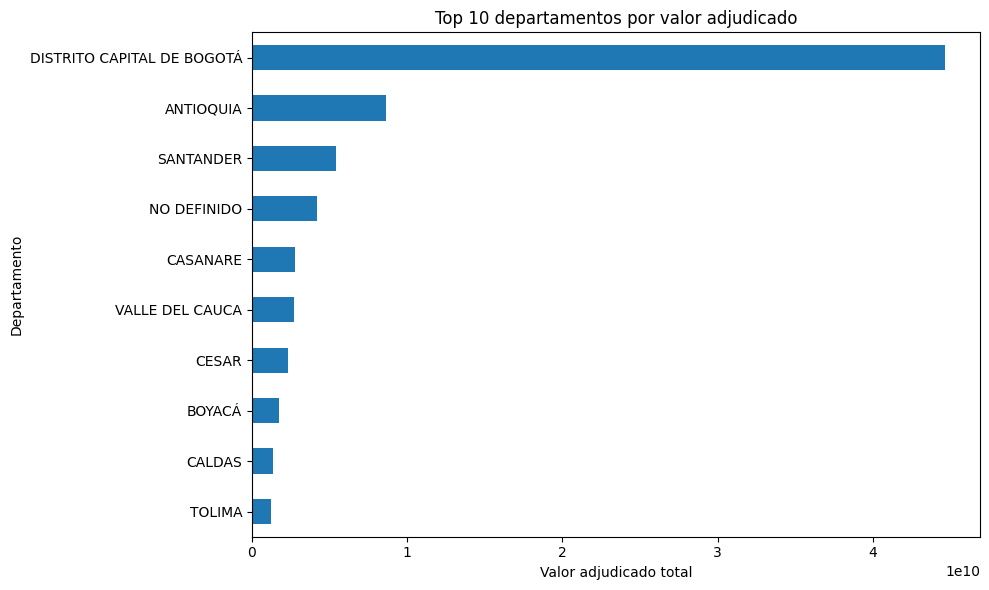

Plot exported: /home/jovyan/output/q1_top_departamentos_valor_adjudicado.png


In [16]:
# SEGMENTO 15 — Plot top departments by adjudicated value

import matplotlib.pyplot as plt

if not q1_departamentos.empty:
    df_plot = q1_departamentos.sort_values(
        "valor_adjudicado_total",
        ascending=True
    )

    ax = df_plot.plot(
        kind="barh",
        x="departamento",
        y="valor_adjudicado_total",
        figsize=(10, 6),
        legend=False
    )

    ax.set_title("Top 10 departamentos por valor adjudicado")
    ax.set_xlabel("Valor adjudicado total")
    ax.set_ylabel("Departamento")

    plt.tight_layout()

    plot_path = OUTPUT_DIR / "q1_top_departamentos_valor_adjudicado.png"
    plt.savefig(plot_path, dpi=150)
    plt.show()

    print("Plot exported:", plot_path)
else:
    print("No data available for plot.")

In [17]:
# SEGMENTO 16 — Total adjudicated value by publication year

q1_anio = (
    ddf_q1
    .dropna(subset=["valor_adjudicado", "anio_publicacion"])
    .groupby("anio_publicacion")["valor_adjudicado"]
    .sum()
    .compute()
    .reset_index()
)

q1_anio.columns = [
    "anio_publicacion",
    "valor_adjudicado_total"
]

q1_anio = q1_anio.sort_values("anio_publicacion")

q1_anio_path = OUTPUT_DIR / "q1_valor_adjudicado_por_anio.csv"
q1_anio.to_csv(q1_anio_path, index=False)

print("Exported:", q1_anio_path)
print(q1_anio.to_string(index=False))

Exported: /home/jovyan/output/q1_valor_adjudicado_por_anio.csv
 anio_publicacion  valor_adjudicado_total
           2015.0                  197000
           2016.0                   12040
           2017.0               790303311
           2018.0              6889730479
           2019.0              9078409700
           2020.0              9838793990
           2021.0              8113644540
           2022.0              7151676160
           2023.0              8411212802
           2024.0             19897124526
           2025.0              8770343068
           2026.0              1319652100


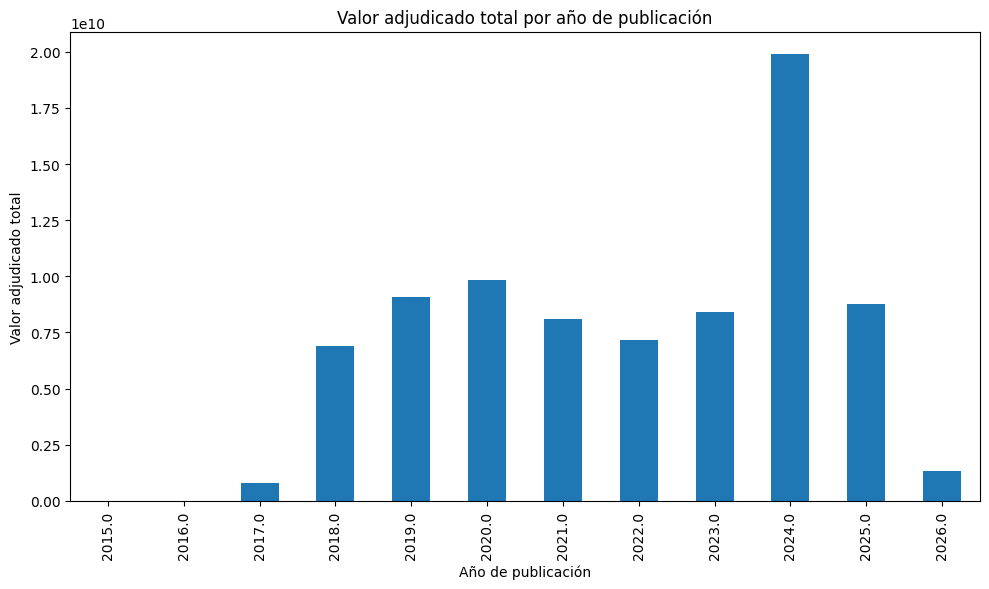

Plot exported: /home/jovyan/output/q1_valor_adjudicado_por_anio.png


In [18]:
# SEGMENTO 17 — Plot adjudicated value by year

if not q1_anio.empty:
    ax = q1_anio.plot(
        kind="bar",
        x="anio_publicacion",
        y="valor_adjudicado_total",
        figsize=(10, 6),
        legend=False
    )

    ax.set_title("Valor adjudicado total por año de publicación")
    ax.set_xlabel("Año de publicación")
    ax.set_ylabel("Valor adjudicado total")

    plt.tight_layout()

    plot_path = OUTPUT_DIR / "q1_valor_adjudicado_por_anio.png"
    plt.savefig(plot_path, dpi=150)
    plt.show()

    print("Plot exported:", plot_path)
else:
    print("No data available for plot.")

In [19]:
# SEGMENTO 18 — Process count by adjudication status

q1_estado = (
    ddf_q1["estado_adjudicacion"]
    .value_counts()
    .compute()
    .reset_index()
)

q1_estado.columns = [
    "estado_adjudicacion",
    "cantidad_procesos"
]

q1_estado_path = OUTPUT_DIR / "q1_cantidad_por_estado_adjudicacion.csv"
q1_estado.to_csv(q1_estado_path, index=False)

print("Exported:", q1_estado_path)
print(q1_estado.to_string(index=False))

Exported: /home/jovyan/output/q1_cantidad_por_estado_adjudicacion.csv
estado_adjudicacion  cantidad_procesos
                 NO               2701
                 SI                299


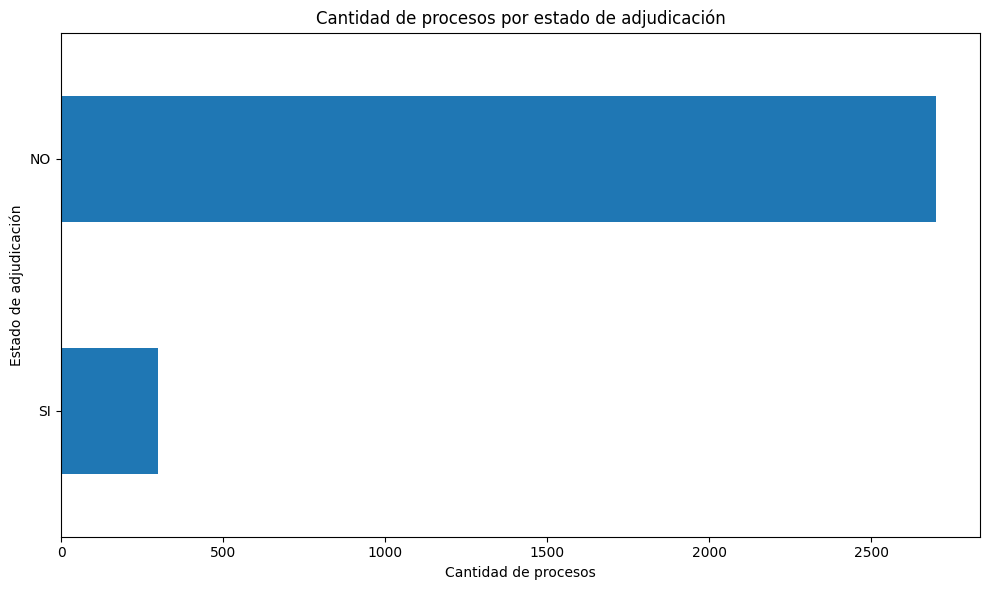

Plot exported: /home/jovyan/output/q1_cantidad_por_estado_adjudicacion.png


In [20]:
# SEGMENTO 19 — Plot process count by adjudication status

if not q1_estado.empty:
    df_plot = q1_estado.sort_values("cantidad_procesos", ascending=True)

    ax = df_plot.plot(
        kind="barh",
        x="estado_adjudicacion",
        y="cantidad_procesos",
        figsize=(10, 6),
        legend=False
    )

    ax.set_title("Cantidad de procesos por estado de adjudicación")
    ax.set_xlabel("Cantidad de procesos")
    ax.set_ylabel("Estado de adjudicación")

    plt.tight_layout()

    plot_path = OUTPUT_DIR / "q1_cantidad_por_estado_adjudicacion.png"
    plt.savefig(plot_path, dpi=150)
    plt.show()

    print("Plot exported:", plot_path)
else:
    print("No data available for plot.")

In [21]:
# SEGMENTO 20 — Department-year analytical table

q1_departamento_anio = (
    ddf_q1
    .dropna(subset=["valor_adjudicado", "anio_publicacion"])
    .groupby(["departamento", "anio_publicacion"])["valor_adjudicado"]
    .sum()
    .compute()
    .reset_index()
)

q1_departamento_anio.columns = [
    "departamento",
    "anio_publicacion",
    "valor_adjudicado_total"
]

q1_departamento_anio = q1_departamento_anio.sort_values(
    ["anio_publicacion", "valor_adjudicado_total"],
    ascending=[True, False]
)

q1_departamento_anio_path = OUTPUT_DIR / "q1_valor_adjudicado_departamento_anio.csv"
q1_departamento_anio.to_csv(q1_departamento_anio_path, index=False)

print("Exported:", q1_departamento_anio_path)
print(q1_departamento_anio.head(30).to_string(index=False))

Exported: /home/jovyan/output/q1_valor_adjudicado_departamento_anio.csv
                            departamento  anio_publicacion  valor_adjudicado_total
              DISTRITO CAPITAL DE BOGOTÁ            2015.0                  197000
              DISTRITO CAPITAL DE BOGOTÁ            2016.0                   12040
              DISTRITO CAPITAL DE BOGOTÁ            2017.0               768880211
SAN ANDRÉS, PROVIDENCIA Y SANTA CATALINA            2017.0                17423100
                                CASANARE            2017.0                 4000000
                               ANTIOQUIA            2017.0                       0
                                   HUILA            2017.0                       0
                             NO DEFINIDO            2017.0                       0
              DISTRITO CAPITAL DE BOGOTÁ            2018.0              6627548866
                               ANTIOQUIA            2018.0               260461613
               

In [22]:
import sys
sys.path.append("/home/jovyan")

from dask.distributed import Client
from modules.q1_concentracion_territorial import Q1ConcentracionTerritorial

client = Client("tcp://dask-scheduler:8786")

DATA_GLOB = "/home/jovyan/sample_data_demo/*.csv"
OUTPUT_DIR = "/home/jovyan/output"

pipeline_q1 = Q1ConcentracionTerritorial(
    data_glob=DATA_GLOB,
    output_dir=OUTPUT_DIR,
    blocksize="64MB",
)

ddf_q1, tabla_top10, resumen_q1 = pipeline_q1.ejecutar_pipeline_q1()

Cargando datos...
Creando universo analítico Q1...
Persistiendo universo analítico...


CancelledError: int-a0390a76-2b18-4626-9add-8a8cd3e776e8